## Goal

In this notebook, we want to use the Metropolis-Hastings algorithm to sample from a target distribution proportional to

$$x^{1.3}(1-x)^{4.2}$$

for values of $x$ in the interval $(0,1)$. This target is proportional to a Beta$(2.3, 5.2)$ density, and we use Metropolis-Hastings here for illustration.

In [12]:
########################## Metropolis-Hastings Algorithm ########################

# Step 1: We start with an initial state drawn from Uniform(0, 1)
# Step 2: We propose the next state using a Uniform(0, 1) proposal
# Step 3: We compute the acceptance probability
# Step 4: We accept or reject and go back to Step 2

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 11,
})

def target_unnormalized(x):
    x = np.asarray(x)
    return np.where((x > 0) & (x < 1), x**1.3 * (1 - x)**4.2, 0.0)

num_samples = int(1e5)
burn_in = 1000

state = np.random.uniform()
all_states = np.zeros(num_samples)
accepts = 0

for i in range(num_samples):
    all_states[i] = state

    proposal_state = np.random.uniform()

    current_val = target_unnormalized(state)
    proposal_val = target_unnormalized(proposal_state)
    acceptance_ratio = proposal_val / current_val if current_val > 0 else 1.0

    if np.random.uniform() < min(1.0, acceptance_ratio):
        state = proposal_state
        accepts += 1

samples = all_states[burn_in:]
acceptance_rate = accepts / num_samples


## Plots

The figures below show the sampled distribution compared with the target, along with a trace plot of the chain.

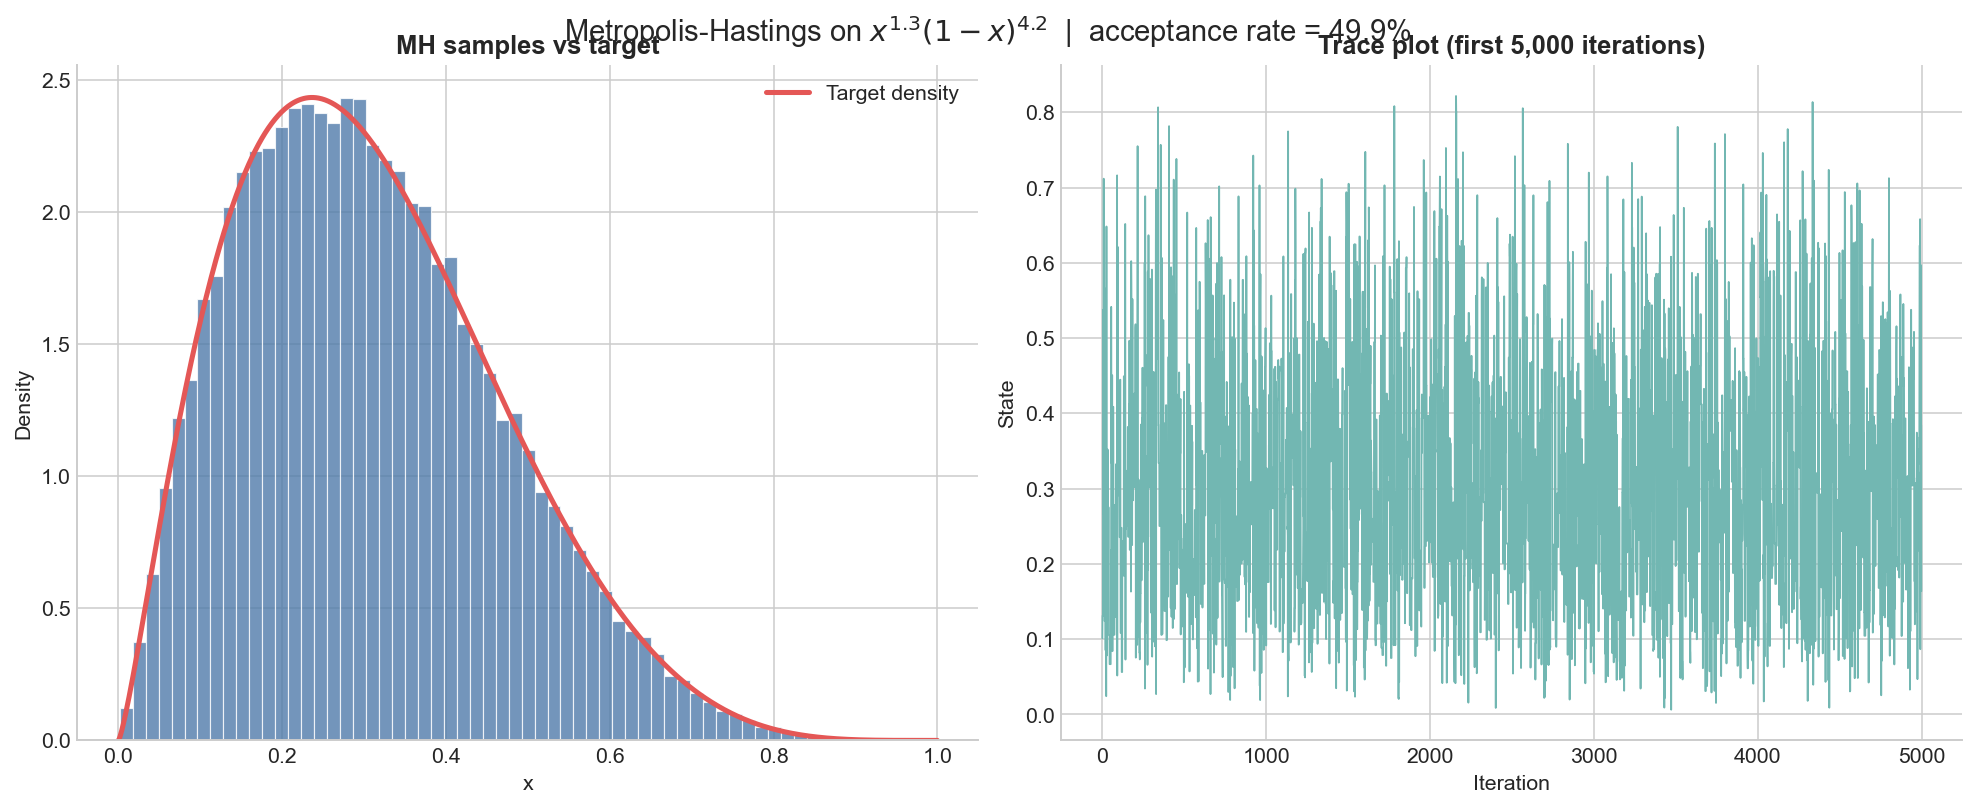

In [14]:
x = np.linspace(0, 1, 1000)
target = target_unnormalized(x)
target /= np.trapz(target, x)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

ax = axes[0]
ax.hist(samples, bins=60, density=True, color="#4C78A8", alpha=0.78, edgecolor="white", linewidth=0.6)
ax.plot(x, target, color="#E45756", lw=2.6, label="Target density")
ax.set_title("MH samples vs target")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.legend(frameon=False)

ax = axes[1]
trace_len = 5000
ax.plot(all_states[:trace_len], color="#72B7B2", lw=0.9)
ax.set_title(f"Trace plot (first {trace_len:,} iterations)")
ax.set_xlabel("Iteration")
ax.set_ylabel("State")
fig.suptitle(
    f"Metropolis-Hastings on $x^{{1.3}} (1-x)^{{4.2}}$  |  acceptance rate = {acceptance_rate:.1%}",
    fontsize=15,
    y=1.02,
)
plt.show()
